## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import random
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.env.station as st
import src.env.car as car_module
import src.env.society as sct
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metric.plots_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


## **UTILS**

### **CONFIG**

In [3]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [4]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

strategy_noise = 0.5  # variation proportionnelle ±50%

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


## **EXPERIMENTS**

### **EVChargingManagement**

#### CONFIG

In [5]:
load_dotenv()
SIM_ID = 'FirstTest'

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
os.makedirs(f'{ROOT_PATH}/{OUTPUT_DIR}', exist_ok=True)

#### SIMULATION PARAMS

In [6]:
total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

strategy_noise = 0.5  # variation proportionnelle ±50%

sim_config = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)


#### **GREEDY APPROACH**

##### *Initialisation*

In [7]:
# ---- OPEN LOG FILES

summary_file = open(f'{ROOT_PATH}/{OUTPUT_DIR}/summary_agents_{SIM_ID}_greedy.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [8]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{ROOT_PATH}/{OUTPUT_DIR}/simulation_{SIM_ID}_greedy.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-24 17:54:45.628 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 0/288
2026-05-24 17:54:45.743 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/288
2026-05-24 17:54:45.756 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/288
2026-05-24 17:54:45.811 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/288
2026-05-24 17:54:45.824 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/288
2026-05-24 17:54:45.851 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/288
2026-05-24 17:54:45.880 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/288
2026-05-24 17:54:45.922 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/288
2026-05-24 17:54:45.951 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/288
2026-05-24 17:54:45.989 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/288
2026-05-24 17:54:46.014 | INFO     | src

In [9]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 0.00 kWh
  Station 2: 0.00 kWh
  Station 3: 0.00 kWh
  Station 4: 22.21 kWh
  Station 5: 3.02 kWh
  Station 6: 2.33 kWh
  Station 7: 0.00 kWh
  Station 8: 2.60 kWh
  Station 9: 0.00 kWh
  Station 10: 8.84 kWh
  Station 11: 0.00 kWh
  Station 12: 0.00 kWh
  Station 13: 0.00 kWh
  Station 14: 0.00 kWh
  Station 15: 1.03 kWh
  Station 16: 2.60 kWh
  Station 17: 0.00 kWh
  Station 18: 1.81 kWh
  Station 19: 0.00 kWh
  Station 20: 0.00 kWh
  Station 21: 0.00 kWh
  Station 22: 0.00 kWh
  Station 23: 0.00 kWh
  Station 24: 0.00 kWh
  Station 25: 1.75 kWh
  Station 26: 1.98 kWh
  Station 27: 9.46 kWh
  Station 28: 1.57 kWh
  Station 29: 4.96 kWh
  Station 30: 13.67 kWh
  Station 31: 0.00 kWh
  Station 32: 2.20 kWh
  Station 33: 17.98 kWh
  Station 34: 3.21 kWh
  Station 35: 1.63 kWh
  Station 36: 3.96 kWh
  Station 37: 0.00 kWh
  Station 38: 9.44 kWh
  Station 39: 0.00 kWh

--- User Request Satisf

##### *Display*

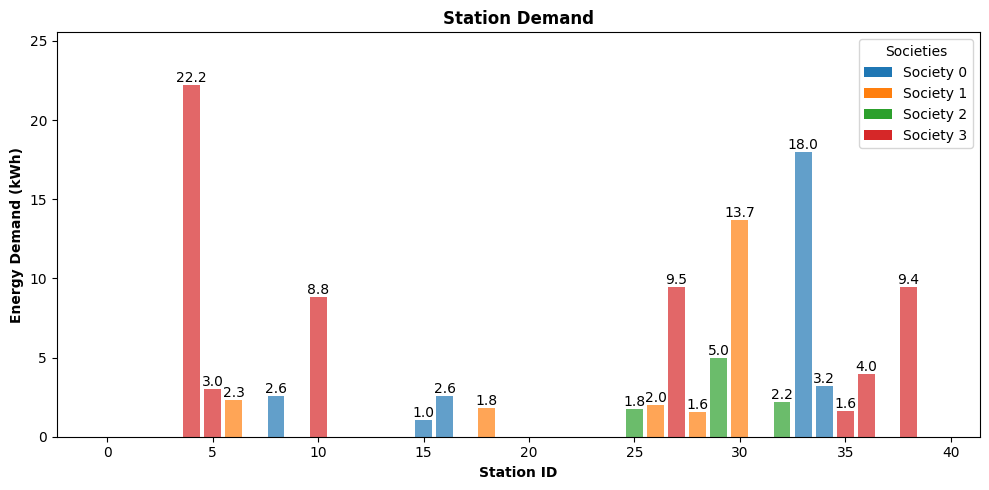

In [10]:
plot_station_demand(greedy_simulation.metrics, societies=societies, figsize=(10, 5))

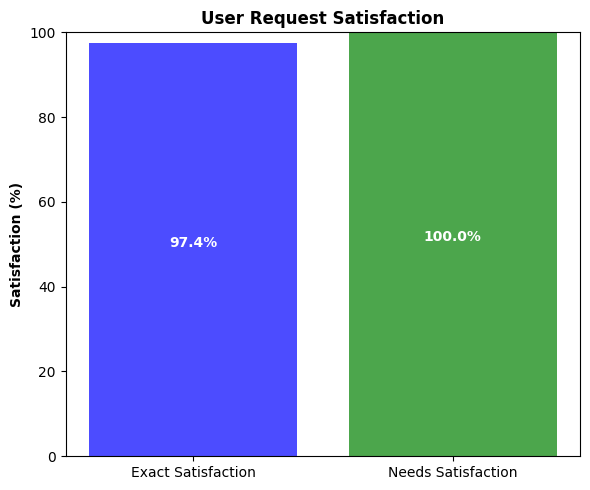

In [11]:
plot_user_satisfaction(greedy_simulation.metrics)

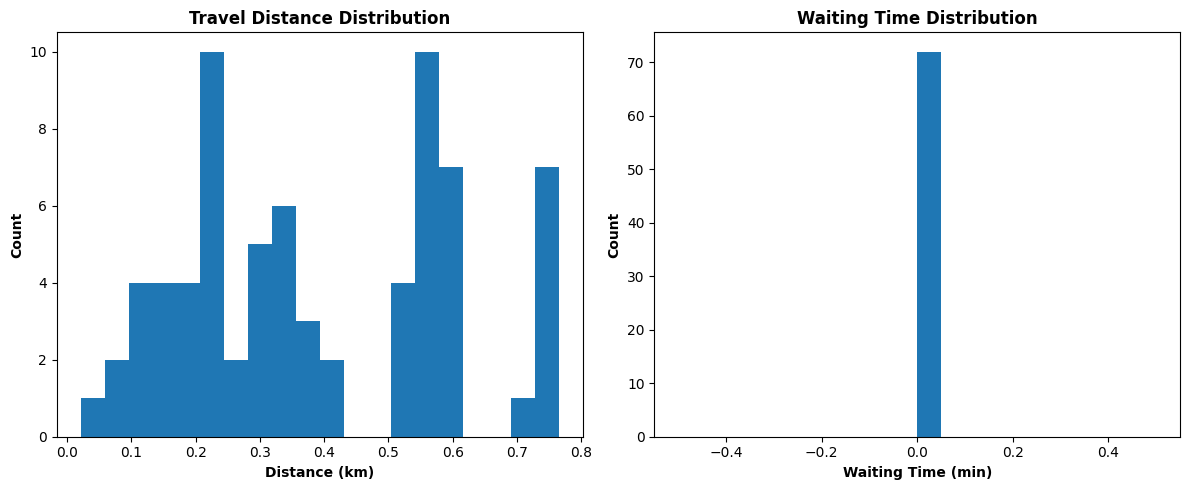

In [12]:
plot_travel_waiting(greedy_simulation.metrics)

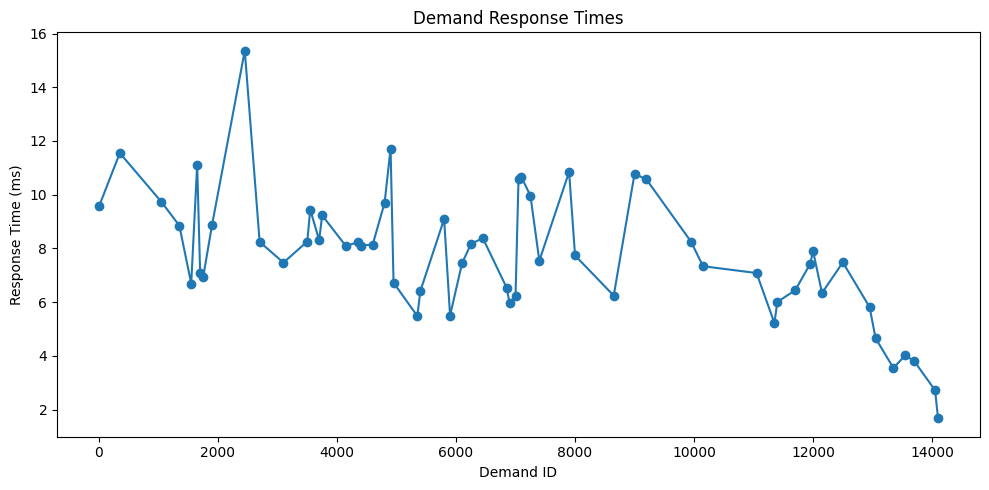

In [13]:
plot_response_times(greedy_simulation.metrics)

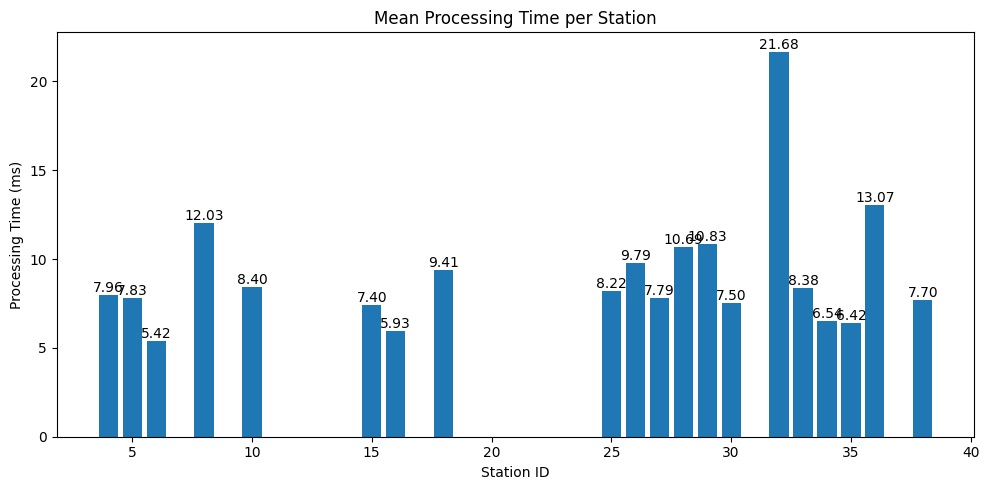

In [14]:
plot_processing_times(greedy_simulation.metrics)

#### Solution

##### *Initialisation*

In [15]:
# ---- OPEN LOG FILES

summary_file = open(f'{ROOT_PATH}/{OUTPUT_DIR}/summary_agents_{SIM_ID}.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [16]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{ROOT_PATH}/{OUTPUT_DIR}/simulation_{SIM_ID}.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-24 17:54:46.680 | INFO     | src.experiments.simulation:step:53 - INSTANT 0/288
2026-05-24 17:54:47.456 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/288
2026-05-24 17:54:47.708 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/288
2026-05-24 17:54:47.778 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/288
2026-05-24 17:54:47.782 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/288
2026-05-24 17:54:47.885 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/288
2026-05-24 17:54:48.147 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/288
2026-05-24 17:54:48.337 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/288
2026-05-24 17:54:48.362 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/288
2026-05-24 17:54:48.508 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/288
2026-05-24 17:54:48.795 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/288
2026-05-24 17:54:49.

In [17]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 6.22 kWh
  Station 2: 9.20 kWh
  Station 3: 2.89 kWh
  Station 4: 3.38 kWh
  Station 5: 14.23 kWh
  Station 6: 5.85 kWh
  Station 7: 0.00 kWh
  Station 8: 0.00 kWh
  Station 9: 1.75 kWh
  Station 10: 0.00 kWh
  Station 11: 5.81 kWh
  Station 12: 0.00 kWh
  Station 13: 0.00 kWh
  Station 14: 2.03 kWh
  Station 15: 0.00 kWh
  Station 16: 11.21 kWh
  Station 17: 4.11 kWh
  Station 18: 0.00 kWh
  Station 19: 3.90 kWh
  Station 20: 0.00 kWh
  Station 21: 0.00 kWh
  Station 22: 15.10 kWh
  Station 23: 0.00 kWh
  Station 24: 5.50 kWh
  Station 25: 1.63 kWh
  Station 26: 0.00 kWh
  Station 27: 0.00 kWh
  Station 28: 0.00 kWh
  Station 29: 1.98 kWh
  Station 30: 2.48 kWh
  Station 31: 0.00 kWh
  Station 32: 4.75 kWh
  Station 33: 0.00 kWh
  Station 34: 5.22 kWh
  Station 35: 0.00 kWh
  Station 36: 0.00 kWh
  Station 37: 0.00 kWh
  Station 38: 12.06 kWh
  Station 39: 2.57 kWh

--- User Request Satis

##### *Display*

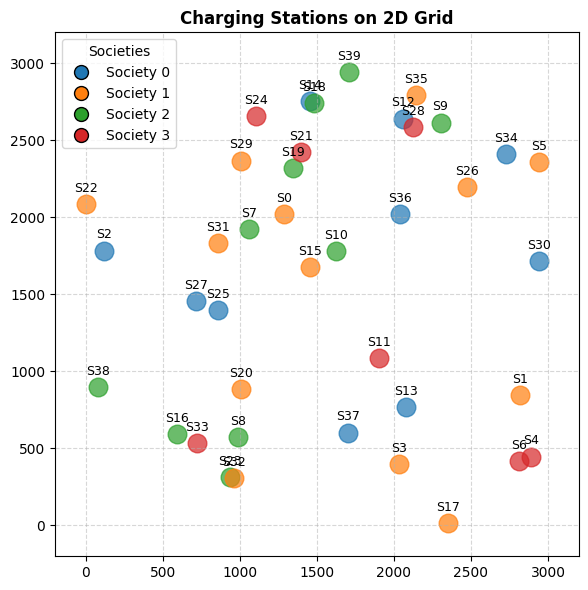

In [18]:
plot_stations_2d(stations, sim_config, figsize=(6, 6), padding=200)

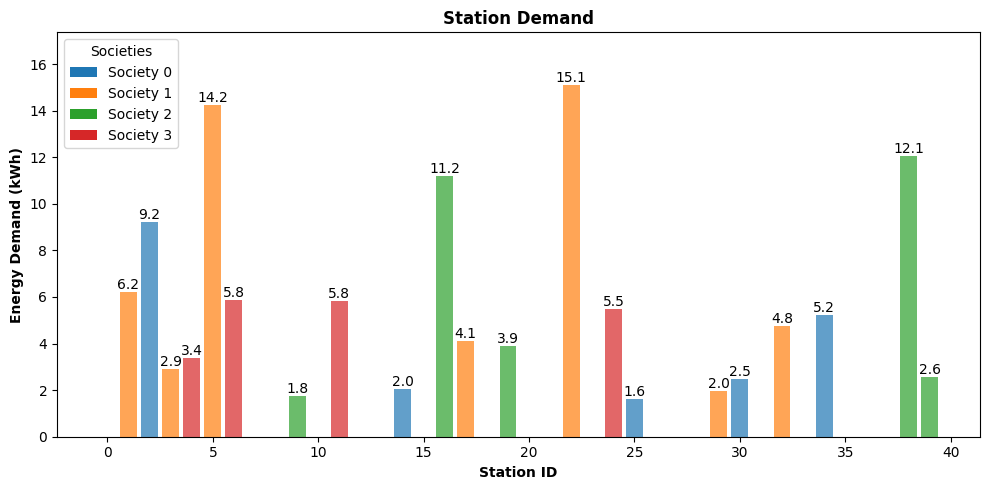

In [19]:
plot_station_demand(simulation.metrics, societies=societies, figsize=(10, 5))

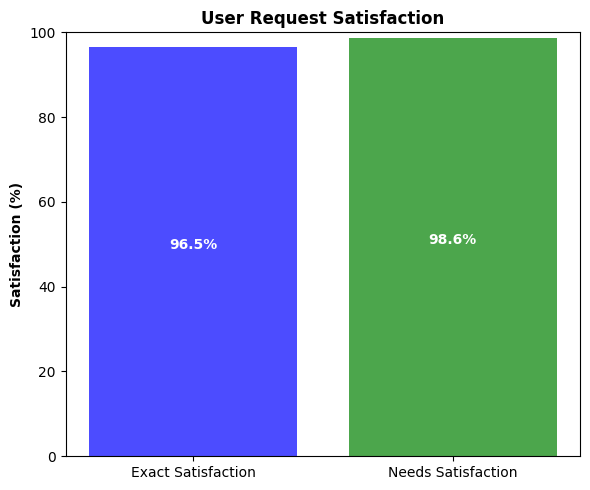

In [20]:
plot_user_satisfaction(simulation.metrics)

In [21]:
def plot_travel_waiting(metrics, bins=20, figsize=(12, 5)):
    """
    Histogrammes :
        - distances parcourues
        - temps d'attente
    """

    if not metrics.acceptance_records:
        print("Aucune acceptance_record disponible.")
        return

    distances = [
        r.distance_km
        for r in metrics.acceptance_records
    ]

    waiting_times = [
        r.waiting_time_h * 60.0
        for r in metrics.acceptance_records
    ]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Distance
    axes[0].hist(distances, bins=bins)
    axes[0].set_title("Travel Distance Distribution", fontweight='bold')
    axes[0].set_xlabel("Distance (km)", fontweight='bold')
    axes[0].set_ylabel("Count", fontweight='bold')

    # Waiting
    axes[1].hist(waiting_times, bins=bins)
    axes[1].set_title("Waiting Time Distribution", fontweight='bold')
    axes[1].set_xlabel("Waiting Time (min)", fontweight='bold')
    axes[1].set_ylabel("Count", fontweight='bold')

    plt.tight_layout()
    plt.show()

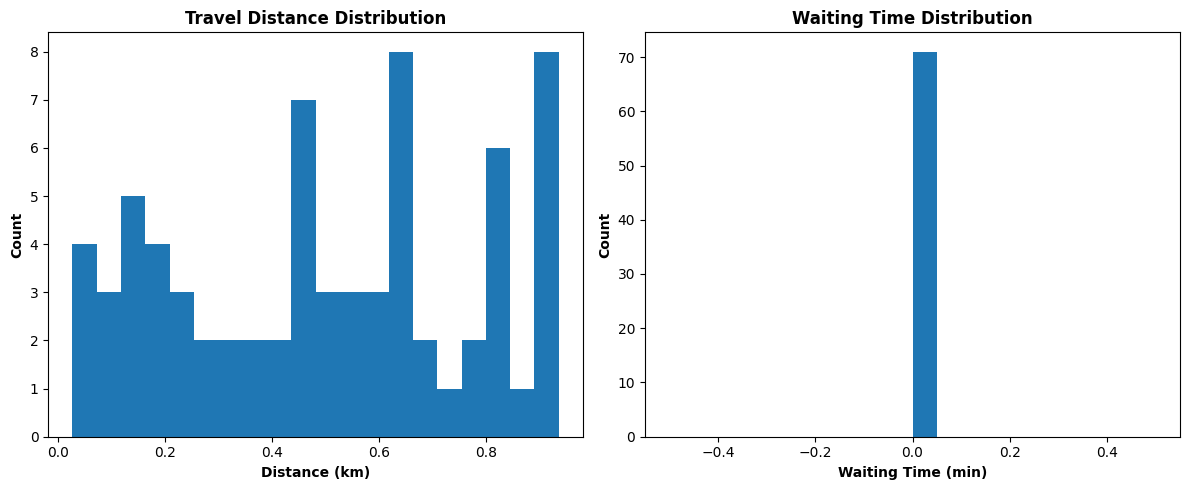

In [22]:
plot_travel_waiting(simulation.metrics)

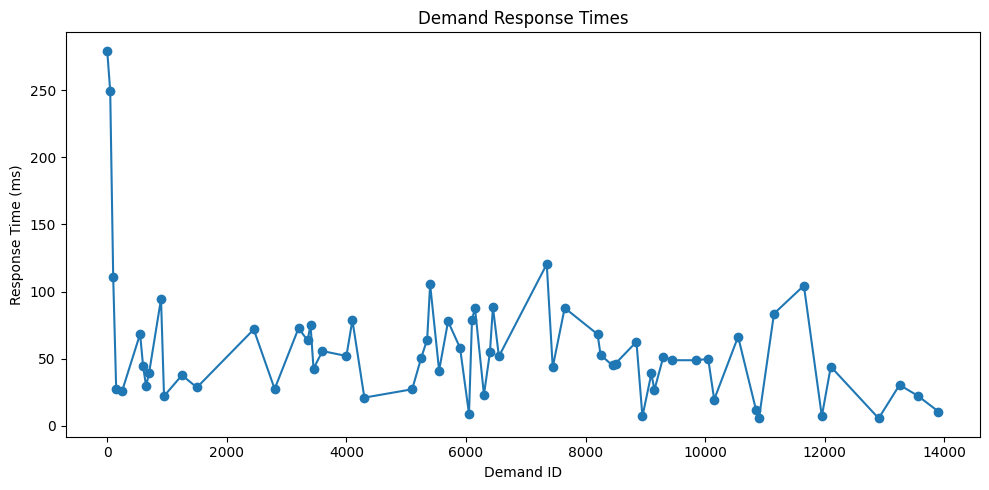

In [23]:
plot_response_times(simulation.metrics)

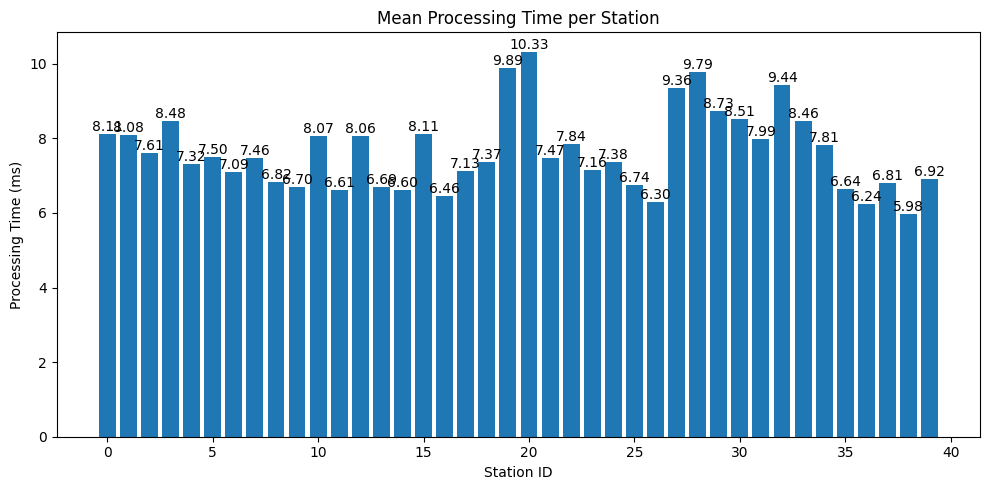

In [24]:
plot_processing_times(simulation.metrics)